In [2]:
class Value:

    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out
    
    
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a*b; e.label = "e"
d = e + c; d.label = "d"
f = Value(-2.0, label="f")
L = d * f; L.label = "L"
L

Value(data=-8.0)

In [3]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot


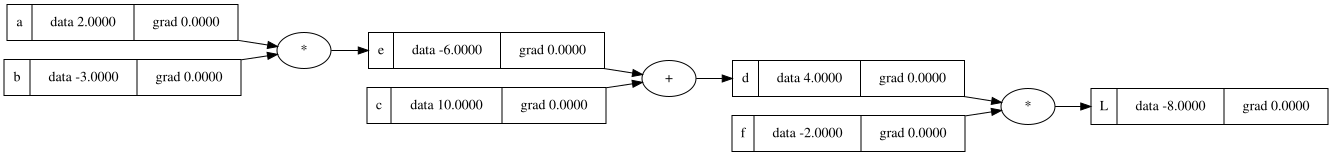

In [4]:
draw_dot(L)

In [5]:
# To deduce the gradient

def lol():
    h = 0.0001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    a = Value(2.0 + h, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L2 = L.data

    print((L2 - L1) / h)

lol()

6.000000000021544


In [6]:
# To deduce the gradient

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    # L2 = L.data
    L2 = L.data + h

    print((L2 - L1) / h)

lol()

1.000000000000334


In [7]:
L.grad = 1

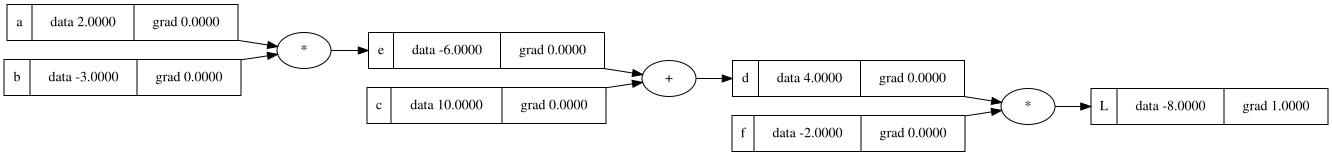

In [8]:
draw_dot(L)

In [9]:
# Theoretical mathematical proof

# L = d * f

# dL/dd =? f

# (f(x+h) - f(x)) / h
# ((d+h)*f - d*f) / h
# (d*f + h*f - d*f) /h
# (h*f) / h
# f

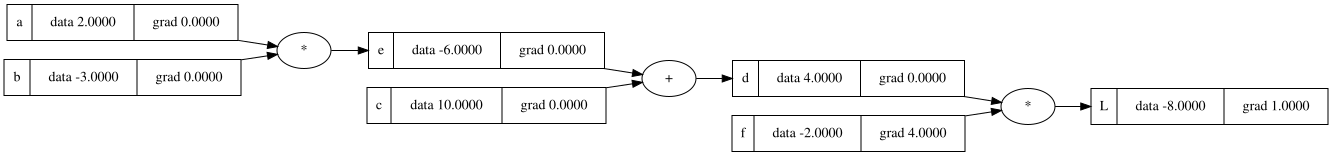

In [10]:
f.grad = d.data
# f.grad = 4

draw_dot(L)

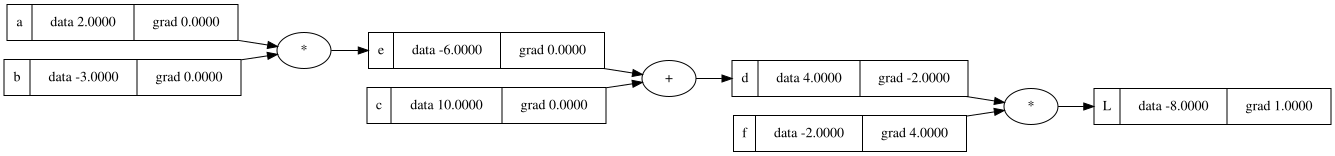

In [11]:
d.grad = f.data
# d.grad = -2

draw_dot(L)

In [12]:
# Imperial proof for f variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    # f = Value(-2.0, label="f")
    f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()

3.9999999999995595


In [13]:
# Imperial proof for d variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    d.data += h
    # f = Value(-2.0, label="f")
    # f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()

-2.000000000000668


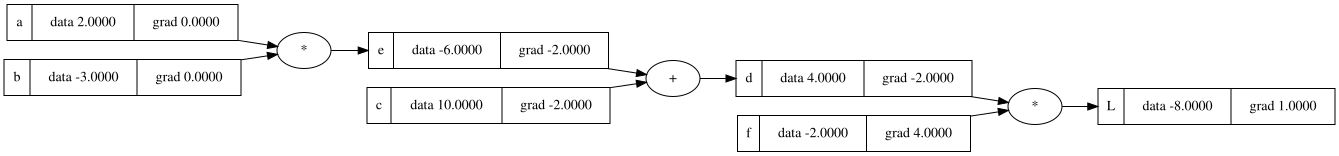

In [16]:
c.grad = d.grad * 1
e.grad = d.grad * 1

draw_dot(L)

In [25]:
# Theoretical mathematical proof

# dL / dc ?

# dd / dc ? 1.0
# dL / dd ? -2.0

# d = c + e

# (f(x+h) - f(x)) / h
# ((c+h + e) - (c + e)) / h
# (c + h + e - c - e) / h
# h / h
# 1.0

# WANT:
# dL / dc

# KNOW:
# dL / dd
# dd / dc
# FROM Chain Rule:
# dL / dc = (dL / dd) * (dd / dc)


In [22]:
# Imperial proof for c variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    c = Value(10.0 + h, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    # d.data += h
    # f = Value(-2.0, label="f")
    # f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()


-1.9999999999988916


In [24]:
# Imperial proof for e variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    # c = Value(10.0 + h, label="c")
    e = a*b; e.label = "e"
    e.data += h
    d = e + c; d.label = "d"
    # d.data += h
    # f = Value(-2.0, label="f")
    # f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()


-2.000000000000668


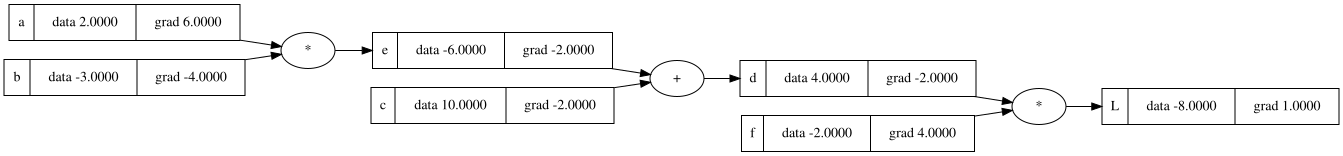

In [26]:
a.grad = b.data * e.grad
b.grad = a.data * e.grad

draw_dot(L)

In [27]:
# Theoretical mathematical proof

# dL / da ?

# de / da ? -3.0
# dL / de ? -2.0

# dL / da = (de / da) * (dL / de)

# (f(x+h) - f(x)) / h
# ((c+h + e) - (c + e)) / h
# (c + h + e - c - e) / h
# h / h
# 1.0

# WANT:
# dL / dc

# KNOW:
# dL / dd
# dd / dc
# FROM Chain Rule:
# dL / dc = (dL / dd) * (dd / dc)


In [29]:
# Imperial proof for a variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    # a = Value(2.0, label="a")
    a = Value(2.0 + h, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    # c = Value(10.0 + h, label="c")
    e = a*b; e.label = "e"
    # e.data += h
    d = e + c; d.label = "d"
    # d.data += h
    # f = Value(-2.0, label="f")
    # f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()


6.000000000000227


In [30]:
# Imperial proof for a variable
# Inline gradient check

def lol():
    h = 0.001

    a = Value(2.0, label="a")
    b = Value(-3.0, label="b")
    c = Value(10.0, label="c")
    e = a*b; e.label = "e"
    d = e + c; d.label = "d"
    f = Value(-2.0, label="f")
    L = d * f; L.label = "L"
    L1 = L.data

    # a = Value(2.0 + h, label="a")
    a = Value(2.0, label="a")
    # a = Value(2.0 + h, label="a")
    # b = Value(-3.0, label="b")
    b = Value(-3.0 + h, label="b")
    c = Value(10.0, label="c")
    # c = Value(10.0 + h, label="c")
    e = a*b; e.label = "e"
    # e.data += h
    d = e + c; d.label = "d"
    # d.data += h
    # f = Value(-2.0, label="f")
    # f = Value(-2.0 + h, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    # L2 = L.data + h

    print((L2 - L1) / h)

lol()


-3.9999999999995595


In [34]:
# The function example:

# L = (a * b + c) * f

# e and d are not inputs

# As the function is polynomial, increasing a, b, c, f variables will increase L

# IF:
# Δa = 0.01 * a.grad
# THEN:
# ΔL ≈ a.grad * Δa

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-6.586368000000001


In [35]:
# The training step is:

# a.data -= lr * a.grad
